# Гипотеза 3

На данных мы увидели, что существуют колонки

1) `num_lab_procedures` (`int`) - число лабороторынх процедур 
2) `time_in_hospital` (`int`) - дни, провереднные в больнице

При возведении больницы существует два крыла - мужское и женское. Для каждого из них нужны свои помещения с оборудованием для процедур.

При планировке больницы, рассчета нагрузки и выделения числа комнат под приемные, важно понимать, будет ли их число одинаковым в мужском и женском отделениях.

Мера, которая показывает интенсивность проведения процедур - **число процедур на день проведения в госпитале**,

то есть *метрика-отношение*.

$$ \frac{\sum_{e} X(e) }{\sum_{e} Y(e)} $$

где

$e$ - событие, в нашем случае - прибывший к нам пациент
$X(e), Y(e)$ - значения `num_lab_procedures` и `time_in_hospital` соответственно у кажого события (посещения больницы)

Заметим, что

$$ \frac{\sum_{e} X(e) }{\sum_{e} Y(e)} = \frac{\overline{X}}{\overline{Y}} $$

То есть наша метрика 


Исследовательский вопрос, который волнует бизнес при строительсве:

**а равны ли эти метрики в группе мужчин и женщин?**

То есть группы берутся по признаку `gender`.

Для этого будем использовать **двусторонний t-test на равенство средних**. 

Но вот незадача, обычно t-test работает только с одним вектором, а в нашей задаче их 2.

Первая мысль, которая приходит в голову - привести два вектора к одному, на уровне события поделив одно на другое. К сожалению, это испортит нам метрику. Доказывающий это контрпример:


| Пациент | Процедуры (X) | Дни (Y) | X/Y | E\[X/Y\] |
|---------|:-------------:|:-------:|:---:|:--------:|
| $e_1$   | 50            | 2       | 25  | 10.3     |
| $e_2$   | 3             | 1       | 3   | 10.3     |
| $e_3$   | 6             | 2       | 3   | 10.3     |

теперь считаем по-другому

$E[X] = (50 + 3 + 6) / 3 = 19.7$ средние процедуры по дню

$E[Y] = (2 + 1 + 2) / 3  = 1.67$ средняя продолжительность лечения

$\frac{E[X]}{E[Y]} = 11.8$

$ \frac{E[X]}{E[Y]} \neq E[\frac{X}{Y}] $

плюс цитаты из [статьи](https://www.researchgate.net/profile/Roman-Budylin/publication/322969314_Consistent_Transformation_of_Ratio_Metrics_for_Efficient_Online_Controlled_Experiments/links/5b054bbb45851588c6d4a1aa/Consistent-Transformation-of-Ratio-Metrics-for-Efficient-Online-Controlled-Experiments.pdf) про метрики-отношения:

1)
> Since these
> values are dependent (e.g., the values for sessions of the same user),
> the state-of-the-art t-test could not be applied to correctly measure
> the statistical significance3
> , which makes the work with this metric
> more complicated than with user level ones

2)
> Note that there is a naive
> straightforward approach to construct a user level metric from a
> ratio OEC: calculate the ratio (which constitutes the source OEC)
> for each user individually5
> and consider the average value of this
> individual ratio over users as a new OEC. But, it is well known and
> shown experimentally that the OEC obtained in such a way will not
> preserve both directionality and sensitivity of the ratio OEC.

Но, благо, есть методы, которые позволяют бороться с этим и все равно считать метрики-отношения! 

Их много, но мы остановится на трех

1) **Дельта - метод**

_кратко_: При условии $ \Delta =  \dfrac{ \bar X_t}{ \bar Y_t}  - \dfrac{ \bar X_c}{ \bar Y_c} = 0$, то есть H0, хотим понять распределение $ \Delta $

_тейк 1_: она распределена **номально**, доказывается это через многомерные функции трансформации.

_тейк 2_: мат ожидание 0 по предположению H0

_тейк 3_: дисперсия сложно выводится через разложение Тейлора, но итоговая формула вот такая: 

$$
\mathrm{Var}\left(\frac{X}{Y}\right) \approx  \frac{1}{\mu_Y^2}\cdot\sigma_X^2 
- 2\frac{\mu_X}{\mu_Y^3}\cdot \sigma_{XY}
+ \frac{\mu_X^2}{\mu_Y^4}\cdot\sigma_Y^2
$$

$$
\mathbf{Var}(\dfrac{ \bar X_t}{ \bar Y_t}  - \dfrac{ \bar X_c}{ \bar Y_c}) 
= \sqrt{\hat{\mathbf{Var}} (\dfrac{\bar X_t}{\bar Y_t})  + \hat{\mathbf{Var}} (\dfrac{\bar X_c}{\bar Y_c}) }
$$

и итоговая статистика получается

$$
\dfrac{\dfrac{\bar X_t}{\bar Y_t} - \dfrac{\bar X_c}{\bar Y_c}}{\sqrt{\hat{\mathbf{Var}} (\dfrac{\bar X_t}{\bar Y_t})  + \hat{\mathbf{Var}} (\dfrac{\bar X_c}{\bar Y_c}) }}
\xrightarrow{d} N(0, 1)
$$

в нашем датасете достаточно много данных, чтобы оно сходилось к нормальному по числу степеней свободы ($d$)


2) **Линеаризация первого вида**

_кратко_: монжо свести наблюдения к прокси-метрике, по которой уже считать статистику и равенство средним обычным t-test, ф-ла:

$$ L(e) = X(e) - R^c Y(e) $$

где:

$L(e)$ - прокси-метрика на событие
$X(e)$ - числитель на событие
$Y(e)$ - знаменатель на событие
$R_c$ - значение метрики в контроле


_тейк 1_:

$\bar L^t = \bar Y^t(R^t - R^c), \, \bar L^c = 0$

$\bar L^t - \bar L^c  = \bar Y^t(R^t - R^c)$

_тейк 2_:

изменение метрики _сонаправлено_ , то есть $\text{sgn} \Delta(R^t - R^c) = \text{sgn}  \Delta(\bar L^t - \bar L^c)$

3) **Линеаризация второго вида**

_кратко_: идея такая же как у линеаризации первого вида, только ф-ла получается другая

$$L(u) = \dfrac{\bar X}{\bar Y} + \dfrac{1}{\bar Y} X(u) - \dfrac{\bar X}{\bar Y^2} Y(u)$$

_тейк 1_:

$$\frac{\bar X}{\bar Y} \approx \frac{1}{n}\sum_{u} \left(\dfrac{\mu_X}{\mu_Y} + \dfrac{1}{\mu_Y}X(u) - \dfrac{\mu_X}{\mu_Y^2} Y(u) \right) \stackrel{d}{\rightarrow} \bar L$$

То есть $\bar L$ стремится к среднему совокупности.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.special import betainc

In [68]:
df = pd.read_csv('./data/diabetic_data.csv')

<Axes: >

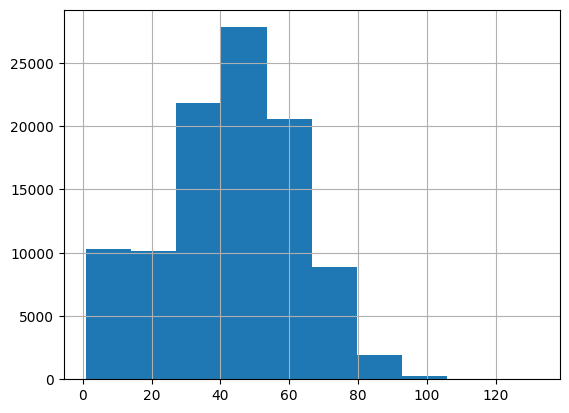

In [69]:
df.num_lab_procedures.hist()

In [70]:
df.num_lab_procedures.describe()

count    101766.000000
mean         43.095641
std          19.674362
min           1.000000
25%          31.000000
50%          44.000000
75%          57.000000
max         132.000000
Name: num_lab_procedures, dtype: float64

заметим, что похоже на нормальное

<Axes: >

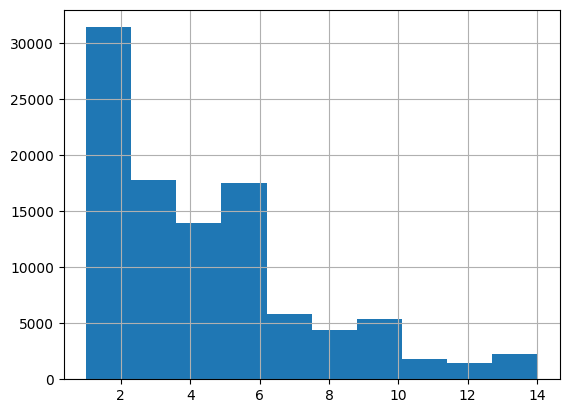

In [71]:
df.time_in_hospital.hist()

In [72]:
df.time_in_hospital.describe()

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

похоже на отрицательное биномиальное

In [73]:
def safe_divide(x, y):
    try:
        return x / y
    except ZeroDivisionError:
        return np.nan

def welch_ttest(test_event: np.ndarray, control_event: np.ndarray) -> tuple[float, float]:
    n1, n2 = len(test_event), len(control_event)
    
    mean1, mean2 = np.mean(test_event), np.mean(control_event)

    var1 = np.sum((test_event - mean1)**2) / (n1 - 1)
    var2 = np.sum((control_event - mean2)**2) / (n2 - 1)
    var = var1 / n1 + var2 / n2

    df = var**2 / ((var1/n1)**2/(n1-1) + (var2/n2)**2/(n2-1)) 

    t_stat = (mean1 - mean2) / np.sqrt(var)
    p_value = betainc(df / 2, 0.5, df / (df + t_stat**2))

    ts, tpval = stats.ttest_ind(test_event, control_event, equal_var=False)
    assert np.isclose(t_stat, ts) and np.isclose(tpval, p_value), f"{t_stat, ts, tpval, p_value}"
    return t_stat, p_value


def delta_var(numerator, denominator):
    x = numerator
    y = denominator
    n = len(x)
    mu_x = np.mean(x)
    mu_y = np.mean(y)
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    cov_xy = np.cov(x, y, ddof=1)[0][1]    
    delta = safe_divide(safe_divide(var_x,mu_y**2)  - 2*cov_xy*safe_divide(mu_x,mu_y**3) + var_y*safe_divide(mu_x**2,mu_y**4), n)
    return delta


def delta_method(x_num, x_denom, y_num, y_denom):
    n = len(x_num)
    m = len(y_num)
    test_var = delta_var(x_num, x_denom)
    control_var = delta_var(y_num, y_denom)
    sigma = np.sqrt(test_var + control_var)
    delta_estimator = safe_divide(np.mean(x_num), np.mean(x_denom)) - safe_divide(np.mean(y_num), np.mean(y_denom))
    t_stat = safe_divide(delta_estimator, sigma)
    pvalue = 2 * stats.t.sf(np.abs(t_stat), n+m-2)
    return t_stat, pvalue


def linearization_type_1(x_num, x_denom, y_num, y_denom):
    y_num_bar = np.mean(y_num)
    y_denom_bar = np.mean(y_denom)
    y_estimator = safe_divide(y_num_bar, y_denom_bar)
    x_linear = np.array(x_num) - y_estimator*np.array(x_denom)
    y_linear = np.array(y_num) - y_estimator*np.array(y_denom)
    t_stat, p_value = welch_ttest(x_linear, y_linear)
    return t_stat, p_value

def linearization_type_2(x_num, x_denom, y_num, y_denom):
    x_num_bar = np.mean(x_num)
    y_num_bar = np.mean(y_num)
    x_denom_bar = np.mean(x_denom)
    y_denom_bar = np.mean(y_denom)
    x_estimator = safe_divide(x_num_bar, x_denom_bar)
    y_estimator = safe_divide(y_num_bar, y_denom_bar)
    x_linear = x_estimator + safe_divide(1, x_denom_bar)*(np.array(x_num) - x_estimator*np.array(x_denom))
    y_linear = y_estimator + safe_divide(1, y_denom_bar)*(np.array(y_num) - y_estimator*np.array(y_denom))
    t_stat, p_value = welch_ttest(x_linear, y_linear)
    return t_stat, p_value

## Синтетический A/B тест

Займемся проверской того, у какого метода выше мощность. Чем больше n, тем лучше получается оценить дисперсию и тем меньше будет ошибок 2го рода.

Для этого искуственно сгенерируем похожие на наши данные, добавим в одну группу эффект и замерим мощность.


In [74]:
lab = df.num_lab_procedures.describe()
time =  df.time_in_hospital.describe()

def ab_sample(
    num_users: int = 10000,
    effect = 0.0,
    seed: int = None
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)

    lab_mean = lab.loc["mean"]
    lab_std  = lab.loc["std"]

    control_lab = np.clip(
        rng.normal(lab_mean, lab_std, size=num_users).round().astype(int),
        lab.loc["min"],
        lab.loc["max"],
    )
    treatment_lab = np.clip(
        rng.normal(lab_mean * (1 + effect), lab_std, size=num_users).round().astype(int),
        lab.loc["min"],
        lab.loc["max"],
    )

    time_mean = time.loc["mean"]
    time_var  = time.loc["std"] ** 2

    r = time_mean ** 2 / (time_var - time_mean)

    def negbin_p(mu: float) -> float:
        return r / (r + mu)

    control_time = np.clip(
        rng.negative_binomial(r, negbin_p(time_mean), size=num_users),
        time.loc["min"],
        time.loc["max"]
    )
    treatment_time = np.clip(
        rng.negative_binomial(r, negbin_p(time_mean), size=num_users),
        time.loc["min"],
        time.loc["max"]
    )

    return control_lab, control_time, treatment_lab, treatment_time

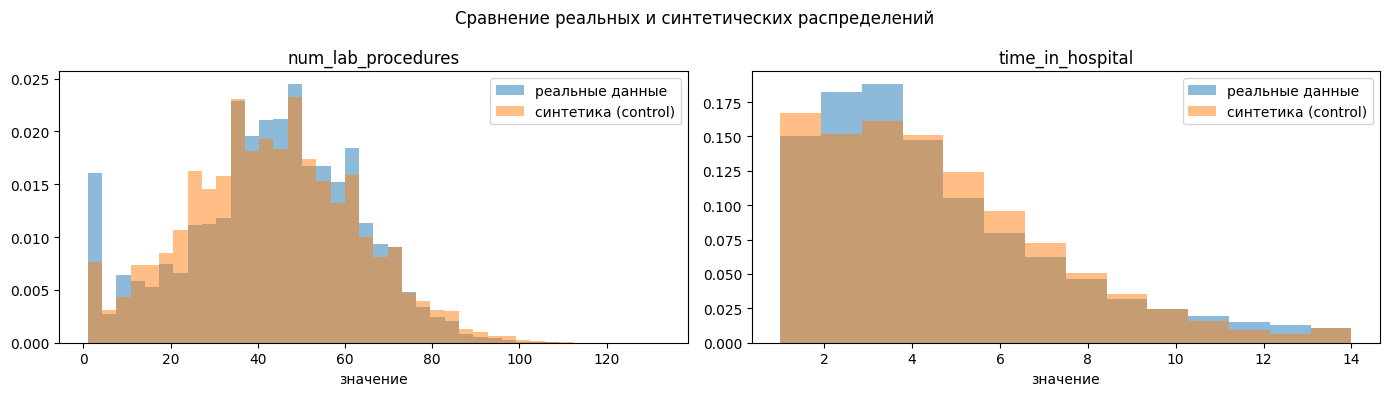

In [75]:
ctrl_lab, ctrl_time, trt_lab, trt_time = ab_sample(num_users=50000, effect=0.0, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# num_lab_procedures
axes[0].hist(df['num_lab_procedures'], bins=40, alpha=0.5, density=True, label='реальные данные')
axes[0].hist(ctrl_lab, bins=40, alpha=0.5, density=True, label='синтетика (control)')
axes[0].set_title('num_lab_procedures')
axes[0].legend()
axes[0].set_xlabel('значение')

real_stats = df['num_lab_procedures'].describe()
synt_stats = pd.Series(ctrl_lab).describe()

# time_in_hospital
axes[1].hist(df['time_in_hospital'], bins=14, alpha=0.5, density=True, label='реальные данные')
axes[1].hist(ctrl_time, bins=14, alpha=0.5, density=True, label='синтетика (control)')
axes[1].set_title('time_in_hospital')
axes[1].legend()
axes[1].set_xlabel('значение')


plt.suptitle('Сравнение реальных и синтетических распределений')
plt.tight_layout()
plt.show()

Не будем проводить стат тестов на то, что данные пришли из одного распределения, но видим, что подгадываем мы довольно точно.

### Сравнение мощности

In [76]:
from tqdm import tqdm

n_sizes = [100, 300, 500, 800, 1000, 1200, 1500, 2000, 4000, 5000]

n_simulations = 1000
effect = 0.05
alpha = 0.05

power_lin1  = []
power_lin2  = []
power_delta = []

for n in n_sizes:
    cnt_lin1 = cnt_lin2 = cnt_delta = 0

    for _ in tqdm(range(n_simulations), desc=f'n={n}'):
        x_num, x_denom, y_num, y_denom = ab_sample(n, effect=effect)

        _, p1 = linearization_type_1(x_num, x_denom, y_num, y_denom)
        _, p2 = linearization_type_2(x_num, x_denom, y_num, y_denom)
        _, p3 = delta_method(x_num, x_denom, y_num, y_denom)

        if p1 < alpha: cnt_lin1  += 1
        if p2 < alpha: cnt_lin2  += 1
        if p3 < alpha: cnt_delta += 1

    power_lin1 .append(cnt_lin1  / n_simulations)
    power_lin2 .append(cnt_lin2  / n_simulations)
    power_delta.append(cnt_delta / n_simulations)

n=5000: 100%|██████████| 1000/1000 [00:01<00:00, 765.07it/s]


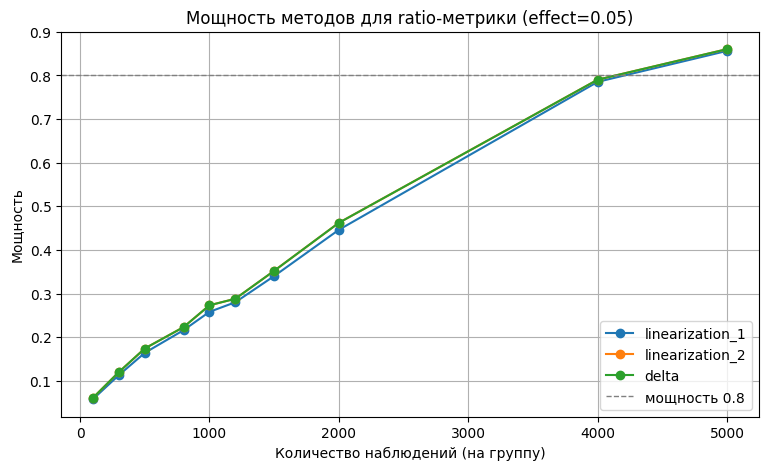

In [77]:
plt.figure(figsize=(9, 5))

plt.plot(n_sizes, power_lin1,  marker='o', label='linearization_1')
plt.plot(n_sizes, power_lin2,  marker='o', label='linearization_2')
plt.plot(n_sizes, power_delta, marker='o', label='delta')

plt.axhline(0.8, color='gray', linestyle='--', linewidth=1, label='мощность 0.8')

plt.xlabel('Количество наблюдений (на группу)')
plt.ylabel('Мощность')
plt.title(f'Мощность методов для ratio-метрики (effect={effect})')
plt.legend()
plt.grid(True)
plt.show()

Видим две вещи
1) delta-метод чуть лучше 1ой линеаризации
2) нет второй линеаризации. Однако это потому, что она **полсностью** схожа с дельта-методом

In [79]:
max([power_lin2[i] - power_delta[i] for i in range(len(n_sizes))])

0.0

Возьмем вторую линеаризацию. При прочих равных, стоит выбирать линеризацию перед дельта методом, тк к линеаризованным метрикам можно применять методы повышения чувствительности, что, впрочем, не пригодится нам при проверке гипотзы.

## A/A тест

конечно же, проверим валижность критерия на A/A тестах

In [80]:
def ci(
    pvalue_vector: np.array,
    alpha=0.05
) -> tuple[float, float, float]:
    n = len(pvalue_vector)
    n_critical = np.sum(pvalue_vector <= alpha)
    p = n_critical / n
    var = p * (1 - p) / n
    scale = stats.norm.ppf(1-alpha/2)
    eps = np.sqrt(var) * scale
    left_bound = p - eps
    right_bound = p + eps
    return p, left_bound, right_bound


def ks_uniformity_check(
    pvalue_vector: np.ndarray,
):
    n = len(pvalue_vector)
    sorted_pvals = np.sort(pvalue_vector)
    theoretical_cdf = sorted_pvals

    d_plus  = np.max(np.arange(1, n + 1) / n - theoretical_cdf)
    d_minus = np.max(theoretical_cdf - np.arange(0, n) / n)

    print(d_plus.shape)

    D_n = max(d_plus, d_minus)
    lam = np.sqrt(n) * D_n

    p_value = 2 * sum(
        ((-1) ** (k - 1)) * np.exp(-2 * k**2 * lam**2)
        for k in range(1, 100) 
    )
    p_value = np.clip(p_value, 0, 1)

    # ks_stat, ks_pval = stats.kstest(pvalue_vector, 'uniform', args=(0, 1))
    # assert np.isclose(D_n, ks_stat, atol=1e-6) \
    #        and np.isclose(ks_pval, p_value, atol=1e-2), f"something went wrong {D_n, ks_stat, p_value, ks_pval}"

    return D_n, p_value


def plot_comparison_with_uniform(
    pvalue_vector: list,
    title: str,
    aplha=0.05,
    color='orange'
):
    pvalue_vector = np.array(pvalue_vector)
    n = len(pvalue_vector)
    p, left_boundary, right_boundary = ci(pvalue_vector, aplha)
    print(f"Ошибка I рода: {round(p, 4)},\nCI для oшибки I рода: [{round(left_boundary, 4)}, {round(right_boundary, 4)}]")

    _, ax1 = plt.subplots(1, 3, figsize=(17, 5))

    # Гистограмма P-value
    ax1[0].hist(pvalue_vector, bins=30, edgecolor='black', alpha=0.6, color=color)
    ax1[0].set_title(
        f'распределение P-value'
    )
    ax1[0].set_xlabel('P-value')
    ax1[0].set_ylabel('Частота')

    # QQ-график
    stats.probplot(pvalue_vector, dist=stats.uniform, plot=ax1[1])
    ax1[1].get_lines()[1].set_linestyle('--')
    ax1[1].set_title(f'{title} (QQ-график)')

    # Эмпирическая функция распределения
    sorted_pvalue_vector = sorted(pvalue_vector)
    ordinal_positions = np.arange(1, n+1) / n
    x_uniform = np.linspace(0, 1, 100)
    cdf_uniform = x_uniform

    ax1[2].step(sorted_pvalue_vector, ordinal_positions, where='post', label='Эмпирическая ФР', color=color)
    ax1[2].plot(x_uniform, cdf_uniform, 'k--', label='Теоретическая CDF $U[0,1]$')
    ax1[2].set_title('Эмпирическая и теоретическая ФР')
    ax1[2].set_xlabel('p-value')
    ax1[2].set_ylabel('dist(p-value)')

    # Тест Колмогорова-Смирнова
    ks_statistic, ks_p_value = ks_uniformity_check(pvalue_vector)
    print(f'Статистика Колмогорова-Смирнова: {round(ks_statistic, 4)}, pvalue для сравнения ЭФР с равномерным: {round(ks_p_value, 4)}')
    if ks_p_value < 0.05:
        print("Гипотеза H0 отвергается: выборка НЕ из равномерного U(0,1)")
    else:
        print("Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)")

    ax1[2].text(
        0.05, 0.9,
        f"KS: stat={ks_statistic:.3f}\np={ks_p_value:.3f}",
        fontsize=10,
        verticalalignment='top',
        bbox={"boxstyle": "round", "facecolor": "w"}
    )
    plt.tight_layout()
    plt.show()


def student_ttest(test_event: np.ndarray, control_event: np.ndarray) -> tuple[float, float]:
    n1, n2 = len(test_event), len(control_event)
    df = n1 + n2 - 2
    mean1, mean2 = np.mean(test_event), np.mean(control_event)

    var1 = np.sum((test_event - mean1)**2) / (n1 - 1)
    var2 = np.sum((control_event - mean2)**2) / (n2 - 1)
    var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)

    t_stat = (mean1 - mean2) / np.sqrt(var * (1/n1 + 1/n2))
    p_value = betainc(df / 2, 0.5, df / (df + t_stat**2))

    ts, tpval = stats.ttest_ind(test_event, control_event)
    assert np.isclose(t_stat, ts) and np.isclose(tpval, p_value), f"{t_stat, ts, tpval, p_value}"
    return t_stat, p_value


def welch_ttest(test_event: np.ndarray, control_event: np.ndarray) -> tuple[float, float]:
    n1, n2 = len(test_event), len(control_event)
    
    mean1, mean2 = np.mean(test_event), np.mean(control_event)

    var1 = np.sum((test_event - mean1)**2) / (n1 - 1)
    var2 = np.sum((control_event - mean2)**2) / (n2 - 1)
    var = var1 / n1 + var2 / n2

    df = var**2 / ((var1/n1)**2/(n1-1) + (var2/n2)**2/(n2-1)) 

    t_stat = (mean1 - mean2) / np.sqrt(var)
    p_value = betainc(df / 2, 0.5, df / (df + t_stat**2))

    ts, tpval = stats.ttest_ind(test_event, control_event, equal_var=False)
    assert np.isclose(t_stat, ts) and np.isclose(tpval, p_value), f"{t_stat, ts, tpval, p_value}"
    return t_stat, p_value


In [81]:
n = 2000

num_male = df.loc[(df["gender"] == "Male"), "num_lab_procedures"]
denom_male = df.loc[(df["gender"] == "Male"), "time_in_hospital"]
pval_lin2 = []

for i in range(n):
    indices = np.random.binomial(1, 0.5, len(num_male)).astype(bool)
    control_num = num_male.loc[indices]
    control_denom = denom_male.loc[indices]
    treatment_num = num_male.loc[~indices]
    treatment_denom = denom_male.loc[~indices]
    _, p_val_c = linearization_type_2(control_num, control_denom, treatment_num, treatment_denom)
    pval_lin2.append(p_val_c)

Ошибка I рода: 0.047,
CI для oшибки I рода: [0.0377, 0.0563]
()
Статистика Колмогорова-Смирнова: 0.0209, pvalue для сравнения ЭФР с равномерным: 0.348
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


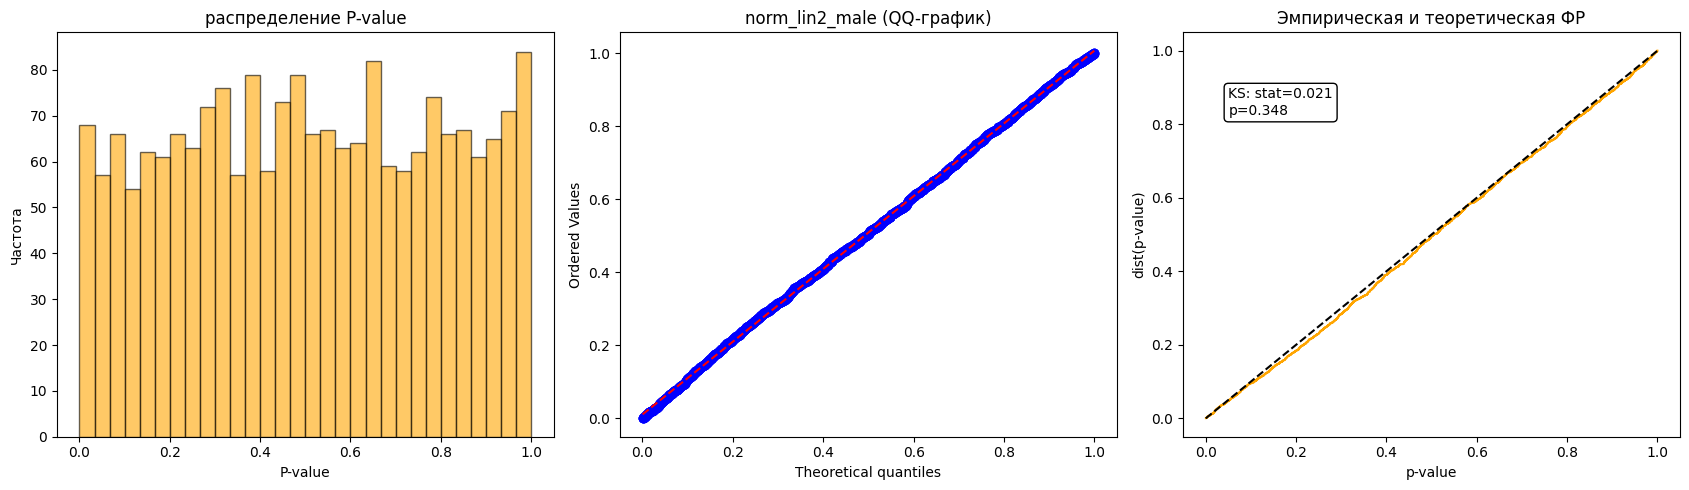

In [82]:
plot_comparison_with_uniform(pval_lin2, "norm_lin2_male")

In [83]:
n = 2000

num_female = df.loc[(df["gender"] == "Female"), "num_lab_procedures"]
denom_female = df.loc[(df["gender"] == "Female"), "time_in_hospital"]
pval_lin2_female = []

for i in range(n):
    indices = np.random.binomial(1, 0.5, len(num_female)).astype(bool)
    control_num = num_female.loc[indices]
    control_denom = denom_female.loc[indices]
    treatment_num = num_female.loc[~indices]
    treatment_denom = denom_female.loc[~indices]
    _, p_val_c = linearization_type_2(control_num, control_denom, treatment_num, treatment_denom)
    pval_lin2_female.append(p_val_c)

Ошибка I рода: 0.053,
CI для oшибки I рода: [0.0432, 0.0628]
()
Статистика Колмогорова-Смирнова: 0.0199, pvalue для сравнения ЭФР с равномерным: 0.409
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


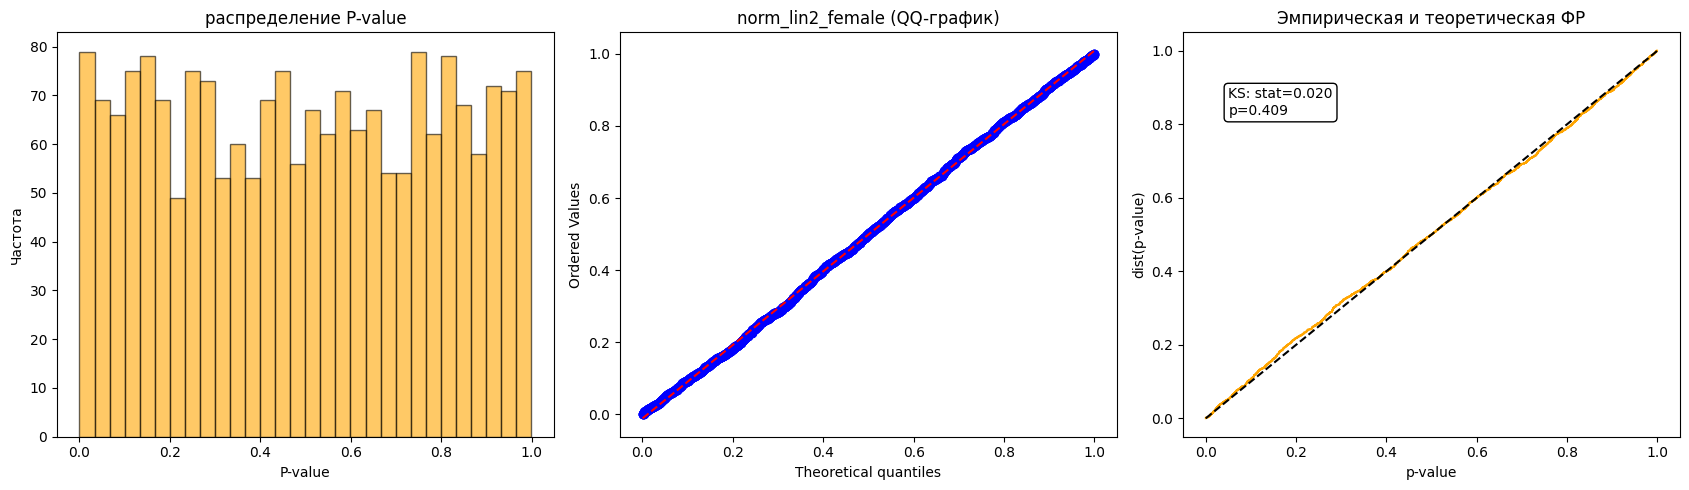

In [84]:
plot_comparison_with_uniform(pval_lin2_female, "norm_lin2_female")

## A/B тест с линеризацией 2го типа

пришло время проверить гипотезу

In [85]:
t_stat, p_val = linearization_type_2(num_male, denom_male, num_female, denom_female)
t_stat, p_val

(np.float64(8.763676829122758), np.float64(1.9193292219311375e-18))

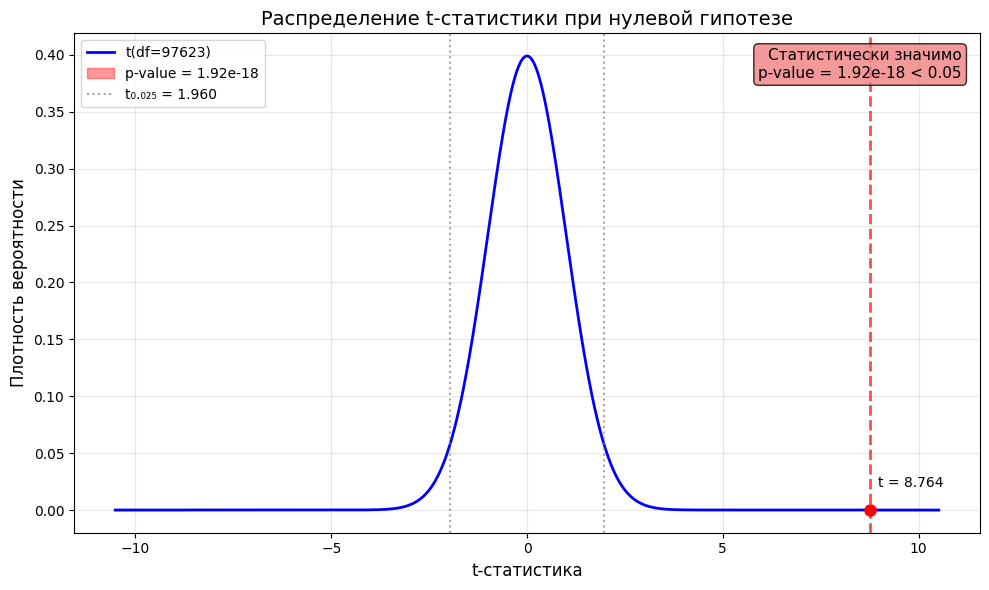

In [86]:
from scipy.optimize import brentq

df_t = brentq(lambda d: 2 * stats.t.sf(abs(t_stat), d) - p_val, 1, 1e8)

fig, ax = plt.subplots(figsize=(10, 6))
plot_max = max(4.5, abs(t_stat) * 1.2)
x_for_plot = np.linspace(-plot_max, plot_max, 2000)

ax.plot(x_for_plot, stats.t.pdf(x_for_plot, df_t), 'b-', linewidth=2, label=f't(df={df_t:.0f})')

ax.fill_between(x_for_plot, stats.t.pdf(x_for_plot, df_t), 0,
                where=(np.abs(x_for_plot) >= abs(t_stat)),
                color='red', alpha=0.4, label=f'p-value = {p_val:.2e}')

ax.axvline(x=t_stat, color='red', linestyle='--', linewidth=2, alpha=0.7)

ax.plot(t_stat, 0, 'ro', markersize=8)

ax.text(t_stat + 0.2, stats.t.pdf(0, df_t) * 0.05, f't = {t_stat:.3f}', fontsize=10, ha='left')

t_critical = stats.t.ppf(0.975, df_t)
ax.axvline(x=t_critical, color='gray', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f't₀.₀₂₅ = {t_critical:.3f}')
ax.axvline(x=-t_critical, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

ax.set_xlabel('t-статистика', fontsize=12)
ax.set_ylabel('Плотность вероятности', fontsize=12)
ax.set_title('Распределение t-статистики при нулевой гипотезе', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

if p_val < 0.05:
    result_text = f'Статистически значимо\np-value = {p_val:.2e} < 0.05'
    box_color = 'lightcoral'
else:
    result_text = f'Не значимо\np-value = {p_val:.2e} ≥ 0.05'
    box_color = 'lightgreen'

ax.text(0.98, 0.97, result_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.8))

plt.tight_layout()
plt.show()

## Интерпретация и выводы

Видим, что есть однозначная разница метрике в двух группах. Женщины, обычно, более интенсивно проходят обследования.

Для **бизнеса** значит, что при постройке важно учитывать дисбаланс как классов по полам, так и интенсивность проводимого лечения.